# MASTER THESIS - model V3

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiThTmTrcn3R3C grey-box model

## Importation

In [65]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiThTmTrcn3R3C
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

Our temporal resolution is 5 minutes

In [66]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'general_data_csv_V3_cleaned' and processed to extract relevant variables for the thermal model.

Here are the data from the csv file:
- **Indoor temperature** (`Ti`): Room air temperature measurement
- **Ventilation flow** (`qv`): Fresh air supply
- **CO2 concentration** (`c`): Indoor air quality indicator
- **Damper position** (`MVV`): Ventilation control
- **Outdoor temperature** (`Ta`): Ambient conditions
- **Solar irradiance** (`Ik`): Heat gains from sun
- **Supply water temperature** (`Tfor`): Water inlet temperature to radiators
- **Ventilation supply temperature** (`Tsup`): Fresh air supply temperature

In [107]:
input_df = pd.read_csv('./data/general_data_csv_V3_cleaned.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['MVV'] = input_df['R01_06_MVV01']
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tfor'] = input_df['HTRK_RAD03_TF01']
input_df['Tsup'] = input_df['HTR9_VEN01_TI01']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Th0'] = input_df['Ti'].iloc[0]*1.05
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['Tr0'] = input_df['Tfor'].iloc[0]*0.95
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning
input_df['Phi0'] = 0.5 * (input_df['Th0'] - input_df['Tr0']) / (input_df['Tfor'].iloc[0] - input_df['Tr0']) if (input_df['Tfor'].iloc[0] > input_df['Tr0'].iloc[0]) else 0.1 # Phi0 ≈ (Th0 - Tr0) / (Tfor0 - Tr0)   # From Q = m cp ΔT, m ~ Phi

input_X = input_df[['qv', 'c', 'MVV', 'Ta', 'Ik', 'Tfor', 'Tsup', 'Ti0', 'Th0', 'Tm0', 'Tr0', 'c0', 'N0', 'Phi0']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (34552, 14), input y shape: (34552,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [108]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (27641, 14), y shape: (27641,)
Test: X shape: (6911, 14), y shape: (6911,)


## Model Training Parameters and Physical Constants

The following section defines the physical parameters and initial conditions used for fitting the thermal model. These parameters are based on building geometry, HVAC design standards, and physical constants:

- **Room Surface Area (`S_room`)** (from Revit model)
- **Window Area (`A_windows`)** (from Revit model)
- **Room Height (`H_room`)**: 2.7 m (from Revit model)

   

### Model Parameter Dictionary

The `train_params_TiThTmTrcn3R3C` dictionary contains all model parameters, including:

- Initial conditions for temperatures, CO₂, occupancy, and flow rates
- Thermal capacitances and resistances for air, heater, mass, and envelope
- Internal gains from people and equipment
- Physical constants (air density, specific heat, gravity, etc.)
- Maximum water flow rate (`Phi_max`), allowed to vary between 50% and 150% of the estimated value

These parameters are passed to the model fitting pipeline to calibrate the thermal model to the observed data. The stability of the simulation is verified by printing the time step (`rec_duration`).


In [ ]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)


## Phi_max estimation
Heat_demand = 100                       # W/m² (Denmark winter design) (80-120)
cp_w = 4184                             # J/kgK
Q_design = S_room * Heat_demand         # W
ΔT_water = 10                           #K (supply 50°C → return 40°C typical)
m_max = Q_design / (cp_w * ΔT_water)


# Capacitances initial guesses
# C=ρ×V×c_p [J/K] (ρ density kg/m³, V volume m³, c_p specific heat capacity J/kgK)
rho_air_init = 1.2          # kg/m³
cp_air_init = 1005          # J/kgK
rho_furn_init = 500         # kg/m³
cp_furn_init = 1200         # J/kgK
V_furn_init = 0.1 * V_room  # m³  (10% of room volume as furniture/contents volume)
Ci_i = rho_air_init * V_room * cp_air_init + rho_furn_init * V_furn_init * cp_furn_init

rho_wall = 2200             # kg/m³
cp_conc  = 840              # J/kgK
wall_thickness = 0.1        # m
Cm_i = rho_wall * (S_room * wall_thickness) * cp_conc  

rho_water = 1000            # kg/m³
cp_water  = 4180            # J/kgK
Vol_rad_water = 0.015       # m³  (15 L radiator water volume)
Ch_i =  rho_water * Vol_rad_water * cp_water

tau_valve = 300            # s
DeltaT_typ = 10            # K
Phi_max_init = m_max            # kg/s
Cf_i = (Phi_max_init * tau_valve) / DeltaT_typ


# Resistances initial guesses
# R=1/(U*A) or 1/(h*A) [K/W]
h_rad_conv = 10                # W/m²K
A_rad = 4                      # m²  (radiator surface area)
Rih_i = 1 / (h_rad_conv * A_rad)

h_conv = 8                     # W/m²K
S_int_mass = 0.6 * S_room      # internal surfaces area ~60%
Rim_i = 1 / (h_conv * S_int_mass)

h_water_rad = 5000             # W/m²K
A_fin = 5                      # m²  (radiator finned surface area)
Rfr_i = 1 / (h_water_rad * A_fin)

U_env = 0.25                   # W/m²K
Rout_i= 1 / (U_env * S_room)


# Capacitances and resistances variation ranges
# TUNED FOR FASTER RESPONSE (to capture peaks)
# Key: τ = R × C → smaller τ = faster response = better peak tracking

# CAPACITANCES - allow MUCH smaller values for faster response
Ci_min = 0.01*Ci_i      # Very low - allow fast air response
Ci_max = 2*Ci_i         
Cm_min = 0.02*Cm_i      # Very low - less thermal mass dampening
Cm_max = 3*Cm_i         
Ch_min = 0.1*Ch_i       
Ch_max = 20*Ch_i        # Higher max - heater may need more capacity
Cf_min = 0.2*Cf_i       
Cf_max = 10*Cf_i        # Higher max

# RESISTANCES - allow smaller values for faster heat transfer
Rih_min = 0.01*Rih_i    # Very low - fast heater→air transfer
Rih_max = 3*Rih_i       
Rim_min = 0.05*Rim_i    # Very low - fast air↔mass coupling
Rim_max = 3*Rim_i       
Rfr_min = 0.05*Rfr_i    
Rfr_max = 10*Rfr_i      
Rout_min = 0.05*Rout_i  # Very low - faster outdoor response
Rout_max = 3*Rout_i



# Define training parameters
train_params_TiThTmTrcn3R3C = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Th0': {'value': input_df.iloc[0]['Th0'], 'vary': True, 'min': 5, 'max': 35},   # Initial heater temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'Tr0': {'value': input_df.iloc[0]['Tr0'], 'vary': False},               # Initial return temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    'Phi0': {'value': input_df.iloc[0]['Phi0'], 'vary': False},             # Initial valve opening fraction
    
    'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    'Ch': {'value': Ch_i, 'vary': True, 'min': Ch_min, 'max': Ch_max},      # Radiator heat capacity (how much heat radiator water+metal can store at Th)
    'Cf': {'value': Cf_i, 'vary': True, 'min': Cf_min, 'max': Cf_max},      # Effective heat capacity of radiator water flow + metal (sets radiator output response speed to valve MVV)
    'Rih': {'value': Rih_i, 'vary': True, 'min': Rih_min, 'max': Rih_max},  # Thermal resistance indoor air ↔ radiator (heat from radiator to air)
    'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    'Rfr': {'value': Rfr_i, 'vary': True, 'min': Rfr_min, 'max': Rfr_max},  # Thermal resistance radiator metal ↔ water return (stronger coupling = larger heat transfer to water)
    'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    'Phi_max': {'value': m_max, 'vary': True, 'min': 0.5*m_max, 'max': 1.5*m_max}, # vary between 50% and 150% of estimated max flow rate
    'cp_w': {'value': 4184, 'vary': False},                                 # Specific heat capacity of water
    'g': {'value': 0.35, 'vary': False},                                    # Some constant g
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


Set up our initial conditions parameters map for testing

In [70]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Th0': lambda _X_test, _y_test, train_result: train_result.var['Th'][-1],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'Tr0': lambda X_test, _y_test, train_result: train_result.var['Tr'][-1] if 'Tr' in train_result.var else X_test.iloc[0]['Tr0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
    'Phi0': lambda X_test, _y_test, _train_result: X_test.iloc[0]['Phi0']
}

We need to split our training data set into managable chunks for the prefit stage. `Sklearn` is quite helpful here again, in case we wanted to define the prefit sets to be 1 day (24 hours) long:

In [71]:
prefit_splits = KFold(n_splits=int(len(X_train) / 24), shuffle=False).split(X_train)

To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`:

In [72]:
error_metric = rmse

We can define a prefit "survival threshold" to trim the number of model fits during the training process. Any models achieving a higher error during the prefit stage will not make it into the training stage.

In [73]:
prefit_filter = lambda error: abs(error) < 2

Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well, and while the standard Nelder-Mead and Levenberg-Marquardt methods work well in general, it is worth experimenting with others (see here for a list of supported methods: https://lmfit.github.io/lmfit-py/fitting.html#fit-methods-table).

In [74]:
method = 'nelder'

Setting up is ready! We only need to call the `darkgreyfit` convenience pipeline function that delegates the work to the prefit, train and test low-level procedures running on multiple processes and reducing / cleaning the interim results. The returned `pandas.DataFrame` contains the fit models and their train/test performance evaluation.   


In [75]:
models = [TiThTmTrcn3R3C(train_params_TiThTmTrcn3R3C, rec_duration)]

In [76]:
""" # Print shapes before resampling
print("Before resampling:")
print(f"  X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"  X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Resample to hourly for faster training (12x fewer samples)
# Use mean for most columns, but first for initial conditions
X_train_h = X_train.resample('1h').mean()
y_train_h = y_train.resample('1h').mean()
X_test_h = X_test.resample('1h').mean()
y_test_h = y_test.resample('1h').mean()

# Fill any NaN values that might have been created during resampling
X_train_h = X_train_h.fillna(method='ffill').fillna(method='bfill')
X_test_h = X_test_h.fillna(method='ffill').fillna(method='bfill')

# Update rec_duration to 1 hour
rec_duration_h = 1

# Recreate model with hourly rec_duration
models_h = [TiThTmTrcn3R3C(train_params_TiThTmTrcn3R3C, rec_duration_h)]

print("\nAfter resampling to hourly:")
print(f"  X_train_h shape: {X_train_h.shape}, y_train_h shape: {y_train_h.shape}")
print(f"  X_test_h shape: {X_test_h.shape}, y_test_h shape: {y_test_h.shape}")
print(f"  Train NaN count: {X_train_h.isna().sum().sum()}")
print(f"  Test NaN count: {X_test_h.isna().sum().sum()}") """

' # Print shapes before resampling\nprint("Before resampling:")\nprint(f"  X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")\nprint(f"  X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")\n\n# Resample to hourly for faster training (12x fewer samples)\n# Use mean for most columns, but first for initial conditions\nX_train_h = X_train.resample(\'1h\').mean()\ny_train_h = y_train.resample(\'1h\').mean()\nX_test_h = X_test.resample(\'1h\').mean()\ny_test_h = y_test.resample(\'1h\').mean()\n\n# Fill any NaN values that might have been created during resampling\nX_train_h = X_train_h.fillna(method=\'ffill\').fillna(method=\'bfill\')\nX_test_h = X_test_h.fillna(method=\'ffill\').fillna(method=\'bfill\')\n\n# Update rec_duration to 1 hour\nrec_duration_h = 1\n\n# Recreate model with hourly rec_duration\nmodels_h = [TiThTmTrcn3R3C(train_params_TiThTmTrcn3R3C, rec_duration_h)]\n\nprint("\nAfter resampling to hourly:")\nprint(f"  X_train_h shape: {X_train_h.shape}, y_trai

In [77]:
# Limit data to the first 7 days at native 5-minute resolution (no resampling)
start_date = input_df.index.min()
end_date = start_date + pd.Timedelta(days=7)

input_df_7d = input_df.loc[start_date:end_date]
input_X_7d = input_X.loc[start_date:end_date]
input_y_7d = input_y.loc[start_date:end_date]

X_train = input_X_7d
y_train = input_y_7d
X_test = input_X_7d.copy()
y_test = input_y_7d.copy()

print(f"5-min 7-day slice -> X: {X_train.shape}, y: {y_train.shape}")


5-min 7-day slice -> X: (1729, 14), y: (1729,)


In [118]:
# Run the darkgreyfit
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method='leastsq',
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

2026-01-21 01:29:42,929 darkgreybox  INFO     Training models...
2026-01-21 01:30:03,770 darkgreybox  INFO     Generating predictions for 1 models...
Fitting complete!
DataFrame shape: (1, 13)


In this specific example:
* *Initial Population:* 5 model structures were prefit to 28x 24-hour data chunks resulting in 140 pipelines
* *Fitness Function:* The RMSE of a prefit had to be < 2˚C to survive
* *Selection:* 110 pipelines survived the prefit selection and made it into training on the entire training set 
* (No *Crossover* or *Mutation*)
* *Termination:* Out of the 110 pipelines trained, 11 distinct model results were found (i.e. many pipelines were arriving at the same parameter set results)

In [119]:
df

train                            \
                 start_date                  end_date   
0 2025-04-30 22:00:00+00:00 2025-05-07 22:00:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiThTmTrcn3R3C object at 0...   

                                                                          \
                                        model_result       time   method   
0  DarkGreyModelResult(Z=array([24.6       , 24.5...  20.836479  leastsq   

                                 test                            \
      error                start_date                  end_date   
0  0.653913 2025-04-30 22:00:00+00:00 2025-05-07 22:00:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiThTmTrcn3R3C object at 0...   

                                                                          
                                        model_result      time     error  
0  DarkGreyModelResult(Z=array([24.6       , 24.5...  0.030743  0.659179

We can select the model with the lowest error and display its params

In [80]:
select_idx = df[('train', 'error')].argmin()

model = df.loc[select_idx, ('train', 'model')]
train_results = df.loc[select_idx, ('train', 'model_result')]
test_results = df.loc[select_idx, ('test', 'model_result')]

model.result.params

name,value,initial value,min,max,vary
Ti0,24.6000000,24.6,-inf,inf,False
Th0,6.00842897,25.830000000000002,5.00000000,35.0000000,True
Tm0,24.5987840,24.6,-inf,inf,False
Tr0,5.95026165,37.9518666635,-inf,inf,False
c0,400.000000,423.7321429,-inf,inf,False
N0,0.00000000,0.0,-inf,inf,False
Phi0,-3.03431013,-3.034310125620306,-inf,inf,False
Ci,363563.906,1817818.2000000002,363563.640,3272072.76,True
Cm,1016582.69,2032800.0,1016400.00,5082000.00,True
Ch,188099.991,62700.0,12540.0000,188100.000,True


The results show that the `TiTeThRia` model has a good fit on the training set (R2=0.9612) and the errors are low for both the training and test sets (RMSE 0.3719 and 0.3383 respectively) indicating that the model generalises well for data it hasn't seen before (no overfitting problem).

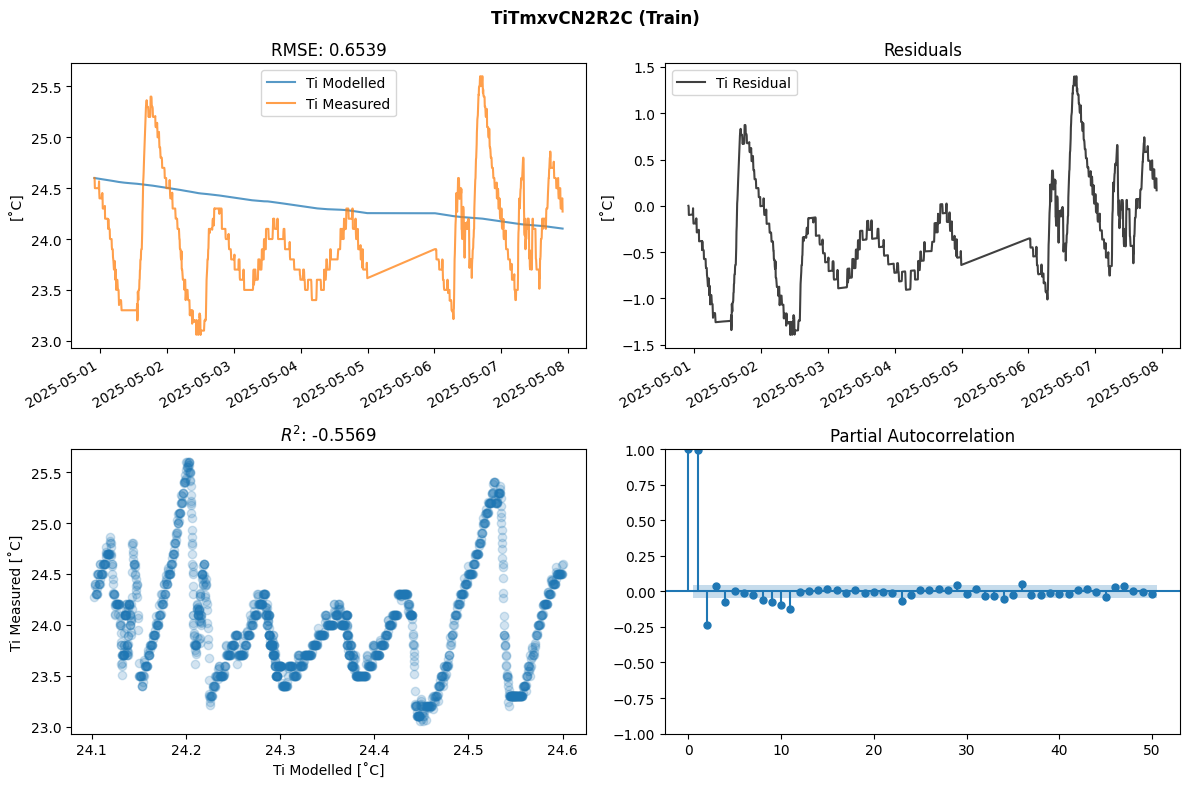

In [81]:
plot(y_train, train_results, 'TiTmxvCN2R2C (Train)')

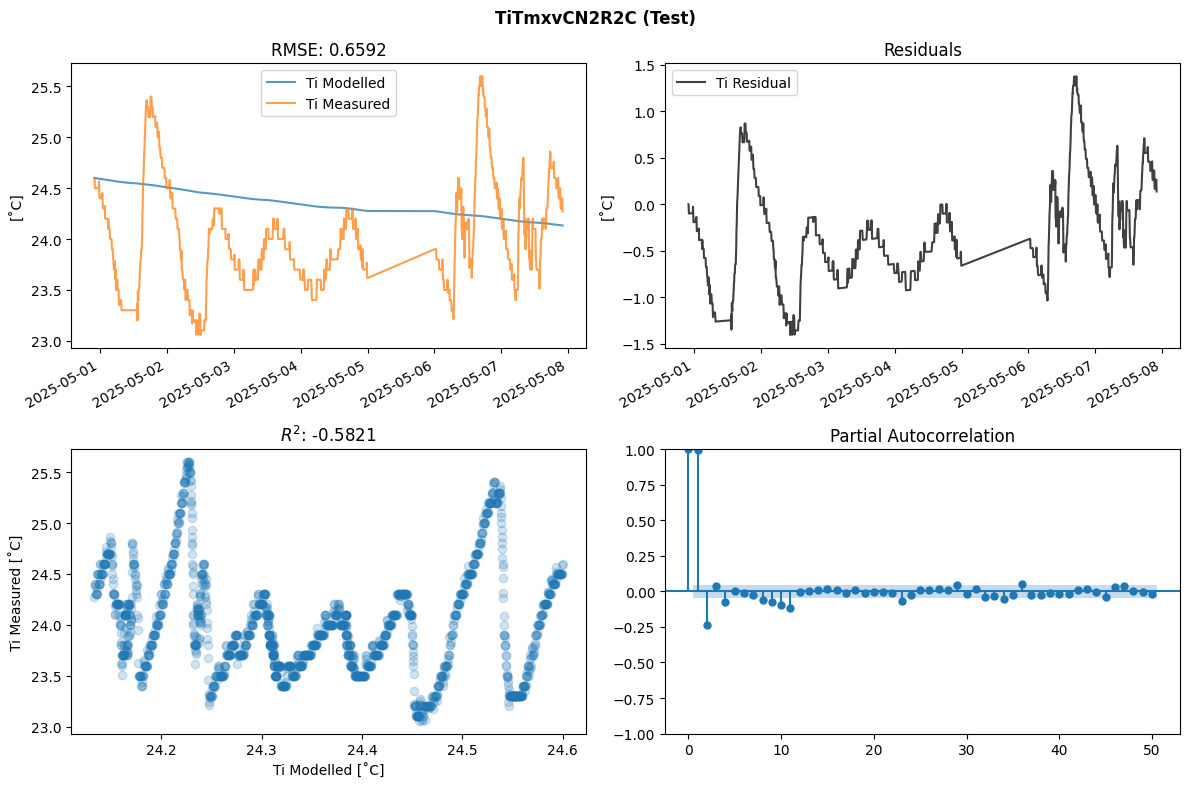

In [82]:
plot(y_test, test_results, 'TiTmxvCN2R2C (Test)')

In [84]:
# DIAGNOSTIC: Why is Ti_modeled not following Ti_measured peaks?
params = model.result.params

print("=" * 80)
print("🔍 DIAGNOSTIC: Why Ti modeled is too smooth")
print("=" * 80)

# 1. Check fitted parameters
print("\n📊 FITTED PARAMETERS:")
print("-" * 80)
print(f"{'Param':<8} {'Initial':>12} {'Fitted':>12} {'Min':>12} {'Max':>12} {'Status'}")
print("-" * 80)

param_issues = []
for name in ['Ci', 'Cm', 'Ch', 'Cf', 'Rih', 'Rim', 'Rfr', 'Rout', 'Phi_max']:
    p = params[name]
    init_val = train_params_TiThTmTrcn3R3C[name]['value']
    status = ""
    if abs(p.value - p.min) < 0.01 * abs(init_val):
        status = "⚠️ AT MIN"
        param_issues.append(f"{name} hit minimum bound")
    elif abs(p.value - p.max) < 0.01 * abs(init_val):
        status = "⚠️ AT MAX"
        param_issues.append(f"{name} hit maximum bound")
    print(f"{name:<8} {init_val:>12.4g} {p.value:>12.4g} {p.min:>12.4g} {p.max:>12.4g} {status}")

# 2. Check time constants
print("\n⏱️ TIME CONSTANTS (τ = R × C in hours):")
print("-" * 80)
tau_heater = params['Rih'].value * params['Ch'].value / 3600
tau_mass = params['Rim'].value * params['Cm'].value / 3600
tau_outdoor = params['Rout'].value * params['Ci'].value / 3600
print(f"τ_heater (Rih×Ch)   = {tau_heater:>8.1f} h  {'⚠️ TOO SLOW' if tau_heater > 2 else '✓ OK'}")
print(f"τ_mass (Rim×Cm)     = {tau_mass:>8.1f} h  {'⚠️ SLOW - dampens daily peaks' if tau_mass > 12 else '✓ OK'}")
print(f"τ_outdoor (Rout×Ci) = {tau_outdoor:>8.1f} h  {'⚠️ SLOW' if tau_outdoor > 24 else '✓ OK'}")

# 3. Check heat inputs - are they varying enough?
print("\n🔥 HEAT INPUT ANALYSIS:")
print("-" * 80)
# Check if heating inputs are varying
MVV_var = X_train['MVV'].std()
Tfor_var = X_train['Tfor'].std()
Ik_var = X_train['Ik'].std()
qv_var = X_train['qv'].std()
print(f"MVV (valve %) std:     {MVV_var:>8.2f}  {'⚠️ LOW - heating barely varies!' if MVV_var < 5 else '✓ OK'}")
print(f"Tfor (supply T) std:   {Tfor_var:>8.2f}°C  {'⚠️ LOW' if Tfor_var < 2 else '✓ OK'}")
print(f"Ik (solar) std:        {Ik_var:>8.2f}  {'⚠️ LOW - no solar variation' if Ik_var < 50 else '✓ OK'}")
print(f"qv (ventilation) std:  {qv_var:>8.2f}  {'⚠️ LOW' if qv_var < 10 else '✓ OK'}")

# 4. Check occupancy - the main cause of peaks!
print("\n👥 OCCUPANCY (main cause of peaks!):")
print("-" * 80)
N0 = train_params_TiThTmTrcn3R3C['N0']['value']
N_varies = train_params_TiThTmTrcn3R3C['N0'].get('vary', False)
print(f"N0 (initial occupancy): {N0}")
print(f"N varies during simulation: {N_varies}")
if N0 == 0 and not N_varies:
    print("⚠️ PROBLEM: Occupancy is ALWAYS ZERO!")
    print("   → No internal gains from people (Q_int = q_equip_const only)")
    print("   → This is likely why peaks are missing!")
    print("\n   💡 FIX: Estimate N from CO2 data:")
    print("      N ≈ V × (dc/dt + qv/V × (c - c_out)) / (G × 1e6)")

# 5. Summary
print("\n" + "=" * 80)
print("📋 SUMMARY - Most likely causes of missing peaks:")
print("=" * 80)
if N0 == 0:
    print("1. 🔴 OCCUPANCY = 0 → No internal gains from people!")
if param_issues:
    print(f"2. 🟡 Parameters at bounds: {', '.join(param_issues)}")
if tau_mass > 12:
    print(f"3. 🟡 Thermal mass time constant ({tau_mass:.0f}h) dampens daily variations")
print("\n💡 RECOMMENDATION: Add time-varying occupancy from CO2 measurements")

🔍 DIAGNOSTIC: Why Ti modeled is too smooth

📊 FITTED PARAMETERS:
--------------------------------------------------------------------------------
Param         Initial       Fitted          Min          Max Status
--------------------------------------------------------------------------------
Ci          1.818e+06    3.636e+05    3.636e+05    3.272e+06 ⚠️ AT MIN
Cm          2.033e+06    1.017e+06    1.016e+06    5.082e+06 ⚠️ AT MIN
Ch           6.27e+04    1.881e+05    1.254e+04    1.881e+05 ⚠️ AT MAX
Cf             0.7887        1.577       0.3944        1.577 ⚠️ AT MAX
Rih             0.025       0.0125       0.0125       0.0375 ⚠️ AT MIN
Rim           0.01894      0.03011     0.007576       0.0303 
Rfr             4e-05        4e-05        1e-05      0.00016 
Rout           0.3636       0.1818       0.1818       0.5455 ⚠️ AT MIN
Phi_max       0.02629      0.03944      0.01315      0.03944 ⚠️ AT MAX

⏱️ TIME CONSTANTS (τ = R × C in hours):
-------------------------------------------

In contrast, the `Ti` model has a poor fit on the training set (R2=0.79) which is clear from the temperature plots as well. Due to low model complexity there is a definite underfitting problem going in here, which of course also results in poor test set performance. This is hardly surprising, as the `Ti` model only keeps internal states of the internal temperatures (`Ti`) and it is unaware of the internal states of the heating system / building envelope temperatures  (`Th` and `Te` respectively) - both of which are important for describing the system components' thermal inertia.

## Using the Kalman Filter Model for Occupancy Estimation

The `TiTmxvCN2R2C_KF` model extends the base model with a Kalman filter that updates the occupancy estimate N at each timestep based on CO2 observations. This allows N to vary over time instead of staying constant.

In [83]:
# Reload the models module to get the new TiTmxvCN2R2C_KF class
importlib.reload(sys.modules['darkgreybox.models'])
from darkgreybox.models import TiTmxvCN2R2C_KF

# Add the CO2 observations to the input data for the Kalman filter
input_df['C_obs'] = input_df['C']  # Use measured CO2 as observations
input_df['P_N0'] = 1.0  # Initial variance of N estimate (constant for all rows)

# Update input_X to include C_obs and P_N0
input_X_kf = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]

# Split for KF model
X_train_kf, X_test_kf, _, _ = train_test_split(input_X_kf, input_y, test_size=0.2, shuffle=False)

# Add Kalman filter parameters to the training params
train_params_KF = train_params_TiTmxvCN2R2C.copy()
train_params_KF['Q_N'] = {'value': 0.5, 'vary': False}     # Process noise for N (persons²/h)
train_params_KF['R_C'] = {'value': 50.0, 'vary': False}    # Measurement noise for CO2 (ppm²)
train_params_KF['P_N0'] = {'value': 1.0, 'vary': False}    # Initial variance of N

print("Training parameters for Kalman Filter model:")
print(f"  Q_N (process noise): {train_params_KF['Q_N']['value']}")
print(f"  R_C (measurement noise): {train_params_KF['R_C']['value']}")

KeyError: 'C'

In [ ]:
# Create and fit the Kalman Filter model
models_kf = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

# Update ic_params_map for KF model
ic_params_map_kf = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: train_result.var['N'][-1],  # Use last estimated N
    'P_N0': lambda X_test, y_test, train_result: train_result.var['P_N'][-1],  # Use last variance
}

df_kf = darkgreyfit(
    models=models_kf,
    X_train=X_train_kf,
    y_train=y_train,
    X_test=X_test_kf,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Kalman Filter model training complete!")

2026-01-18 16:28:37,879 darkgreybox  INFO     Training models...
2026-01-18 16:31:30,650 darkgreybox  INFO     Generating predictions for 1 models...
Kalman Filter model training complete!


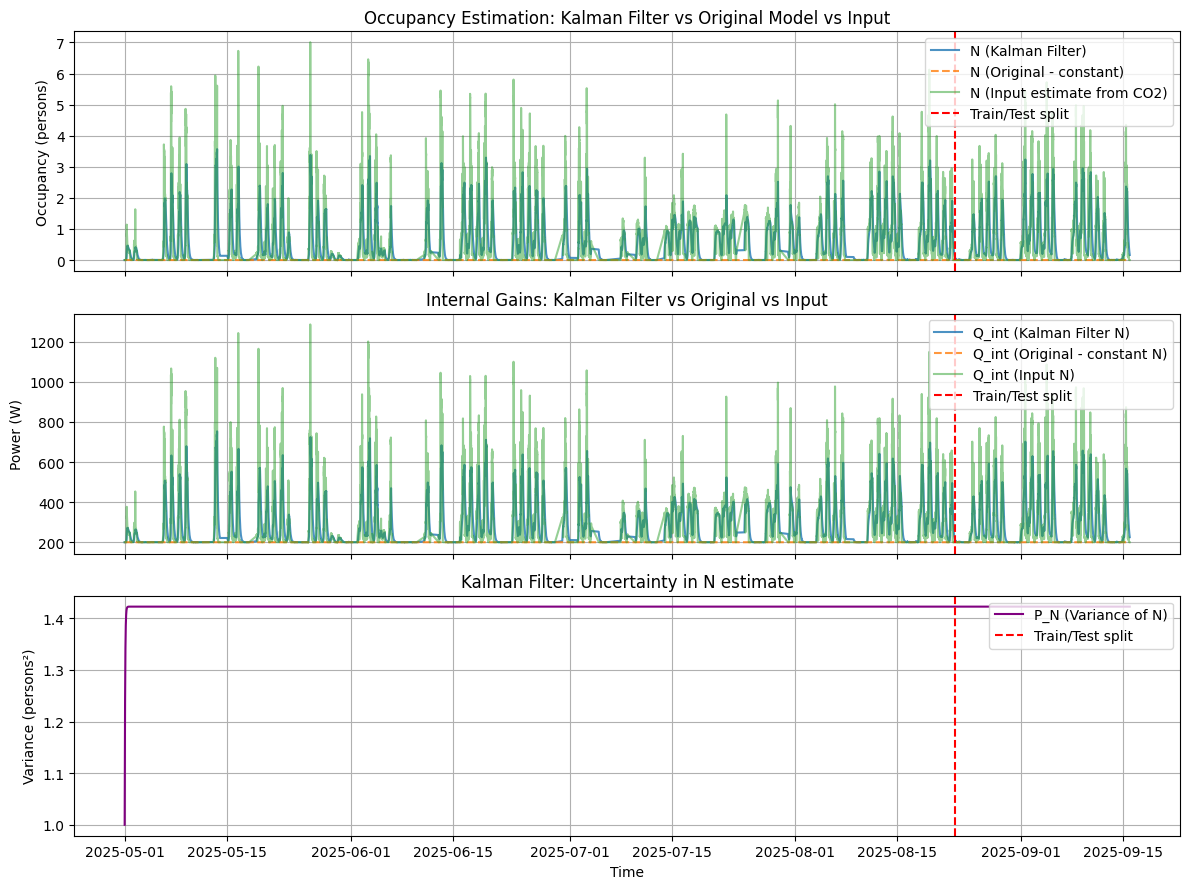


--- Model Comparison ---
Original Model - Train RMSE: 0.6694°C
Original Model - Test RMSE:  0.5648°C
Kalman Filter  - Train RMSE: 0.7193°C
Kalman Filter  - Test RMSE:  0.6548°C


In [ ]:
# Extract results from Kalman Filter model
select_idx_kf = df_kf[('train', 'error')].argmin()
model_kf = df_kf.loc[select_idx_kf, ('train', 'model')]
train_results_kf = df_kf.loc[select_idx_kf, ('train', 'model_result')]
test_results_kf = df_kf.loc[select_idx_kf, ('test', 'model_result')]

# Extract N from original model (non-KF)
N_train = train_results.var['N']
N_test = test_results.var['N']

# Compare N from original model vs Kalman Filter model
N_kf_train = train_results_kf.var['N']
N_kf_test = test_results_kf.var['N']
N_kf_full = np.concatenate([N_kf_train, N_kf_test])

# Get parameters for Q_int calculation
q_pers = train_params_TiTmxvCN2R2C['q_pers']['value']
q_equip_var = train_params_TiTmxvCN2R2C['q_equip_var']['value']
Q_int_const = train_params_TiTmxvCN2R2C['Q_int_const']['value']

# Plot comparison of N estimates
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

idx = input_y.index

# Plot 1: N comparison
axes[0].plot(idx, N_kf_full, label='N (Kalman Filter)', alpha=0.8)
axes[0].plot(idx, np.concatenate([N_train, N_test]), label='N (Original - constant)', linestyle='--', alpha=0.8)
axes[0].plot(input_df.loc[idx, 'N'], label='N (Input estimate from CO2)', alpha=0.5)
axes[0].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[0].set_ylabel('Occupancy (persons)')
axes[0].set_title('Occupancy Estimation: Kalman Filter vs Original Model vs Input')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Q_int comparison
Q_int_kf = Q_int_const + (q_pers + q_equip_var) * N_kf_full
Q_int_orig = Q_int_const + (q_pers + q_equip_var) * np.concatenate([N_train, N_test])
Q_int_input = Q_int_const + (q_pers + q_equip_var) * input_df.loc[idx, 'N'].values
axes[1].plot(idx, Q_int_kf, label='Q_int (Kalman Filter N)', alpha=0.8)
axes[1].plot(idx, Q_int_orig, label='Q_int (Original - constant N)', linestyle='--', alpha=0.8)
axes[1].plot(idx, Q_int_input, label='Q_int (Input N)', alpha=0.5)
axes[1].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[1].set_ylabel('Power (W)')
axes[1].set_title('Internal Gains: Kalman Filter vs Original vs Input')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Variance of N (uncertainty)
P_N_train = train_results_kf.var['P_N']
P_N_test = test_results_kf.var['P_N']
P_N_full = np.concatenate([P_N_train, P_N_test])
axes[2].plot(idx, P_N_full, label='P_N (Variance of N)', color='purple')
axes[2].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[2].set_ylabel('Variance (persons²)')
axes[2].set_xlabel('Time')
axes[2].set_title('Kalman Filter: Uncertainty in N estimate')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print RMSE comparison
print(f"\n--- Model Comparison ---")
print(f"Original Model - Train RMSE: {df.loc[select_idx, ('train', 'error')]:.4f}°C")
print(f"Original Model - Test RMSE:  {df.loc[select_idx, ('test', 'error')]:.4f}°C")
print(f"Kalman Filter  - Train RMSE: {df_kf.loc[select_idx_kf, ('train', 'error')]:.4f}°C")
print(f"Kalman Filter  - Test RMSE:  {df_kf.loc[select_idx_kf, ('test', 'error')]:.4f}°C")

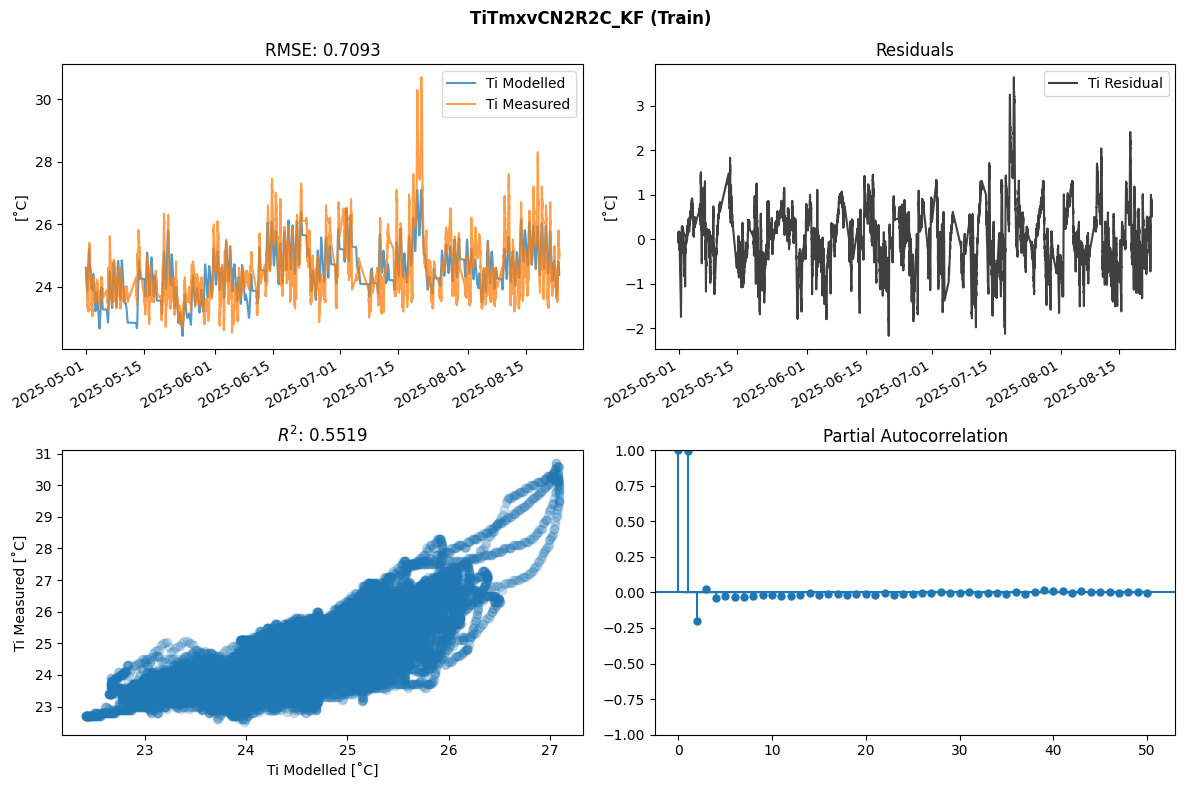

In [ ]:
# Plot Train results for Kalman Filter model
plot(y_train, train_results_kf, 'TiTmxvCN2R2C_KF (Train)')

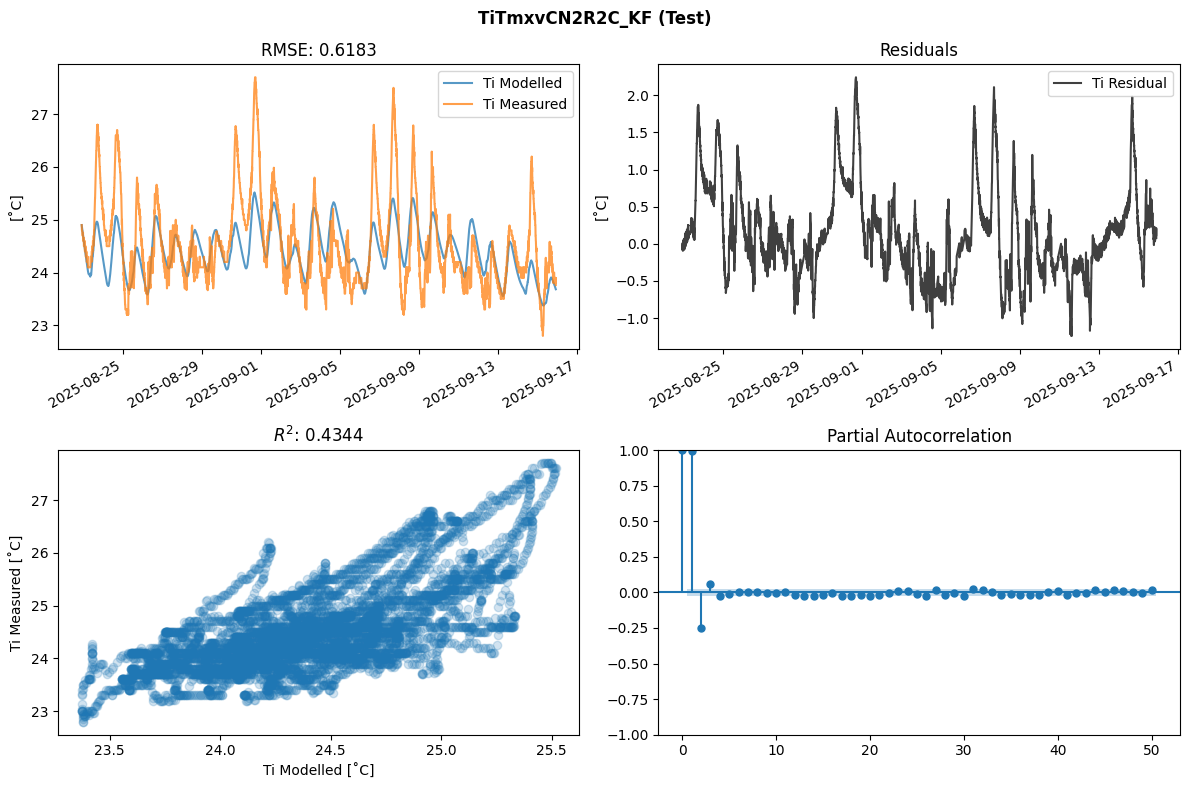

In [ ]:
# Plot Test results for Kalman Filter model
plot(y_test, test_results_kf, 'TiTmxvCN2R2C_KF (Test)')